In [1]:
import os, warnings
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import confusion_matrix
import seaborn as sns

try:
    import wget
except:
    !pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=2d00c49506cb422505466f53d9e85e5ba2aa74dc84978eec38b97118cba78375
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


# Project 2 - Veggie Classification

For this assignment you'll need to classify some images of vegetables.

## Parts

Please do three separate classifications:
<ol>
<li> Create a CNN model from scratch. </li>
<li> Use transfer learning to use a pretrained model of your choice, adapted to this data. </li>
<li> Create some kind of "uncommon" model, one that isn't a regular CNN or fully connected model. This is obviously a vague direction, and there isn't one specific answer. In short, I just want you to use some other model structure and compare the results to the first two. There are several choices here. I won't mark you down for not getting great performance here, or choosing an architecture that performs poorly, but within whatever you choose, the choices to train and optimize that model should be logical. </li>
</ol>

There won't be an explicit evaluation of accuracy, but you should take some steps to make each model as accurate as you reasonably can, any tuning option is fair game. Along with that, please structure it into a notebook that is well-structured and clear that explains what you did and found. Think about:
<ul>
<li> Sections and headings.
<li> A description of the approach taken (e.g. what did you do to determine size, tune, evaluate, etc...)
<li> Visualization of some important things such as a confusion matrix and maybe some images.
<li> Results, mainly focused on the scoring of the test data.
</ul>

The descriptions and explanations should highlight the choices you made and why you made them. Figure up to about a page or so worth of text total, explain what happened but don't write an essay.

## Deliverables

The primary thing that will be graded is the notebook that <b>walks a reader through what you tried and the results</b>, so, please ensure that your workbook:
<ul>
<li> Is published after being fully run, the published version should be a finished copy. </li>
<li> Is organized into sections, using headers, labels, lists, etc... to be easy to read. </li>
<li> Is cleaned up in terms of content. You will likely have some "messing around" with the data preparation to figure out exactly what you need to do. Once you've got it figured out, clean out all the experimentation (you can describe what you did in text). </li>
<li> Presents a conclusion that compares the models, identifies possible things that could make performance better, and identifies what worked and what didn't. </li>
</ul>

### Dataset

The code in the start of this notebook will download and unzip the dataset, and there is also a simple example of creating datasets. You can change the dataset bit to use a different approach if you'd like. The data is already split into train, validation, and test sets. Please treat the separate test set as the final test set, and don't use it for any training or validation. Each folder name is its own label.

### Evaluation

Marking will be based on the following:
<ul>
<li> Data preparation, cleaning, processing, pipeline: 10%. </li>
<li> Modelling and prediction is well done <b>and explained clearly:</b> 60%</li>
    <ul>
    <li> Of the modelling portion:</li>
    <li> Custom model: 50%</li>
    <li> Transfer model: 30%</li>
    <li> Strange model: 20%</li>
    </ul>
<li> Evaluation and comparison: 10%. </li>
<li> Overall ambition: 20%. </li>
    <ul>
    <li> Did you do a reasonable attempt to make a good model, or did you do the minimum to get something that functions. There are a variety of things that you can do to ensure this is a good grade (and it isn't that strict) - trying different architechtures, raytune hp searches, etc...</li>
    </ul>
</ul>

Overall the marking is pretty simple and direct, you want to show everyone that you know how to train some models to predict vegetable classes. Your notebook should demonstrate that knowledge as clearly as possible. <b>Note that you are showing off that you understand predictive modelling and training a model, so you want to demonstrate that here. This doesn't mean that "more is better" and you should throw everything you can do at the problem, but it does mean that "comprehensive is better than 'barely enough'". You want this to show that you know what you're doing. </b>

### Tips

Some hints that may be helpful to keep in mind:
<ul>
<li> If on colab, the environment in which your code runs is temporary - storage will not persist once the session ends. </li>
<li> The data is pretty large, enough so that performance is a concern that you need to consider. In particular, be careful of batch size, you may hit the colab limits. </li>
<li> You may want to build something to manage training in multiple stages - early stopping, saving of weights, reconstructing models, etc... are all helpful things to try to sort from the start. I would figure out some way to start training, and ensure I keep the weights/model no matter what happens after that point, there are several options (generally involving something like google drive), you'll need to do a bit of research. </li>
<li> Consider a sample for quick development cycles to try things out. </li>
<li>

### Download and Unzip Data

In [2]:
def bar_custom(current, total, width=80):
    print("Downloading: %d%% [%d / %d] bytes" % (current / total * 100, current, total))
import wget
import zipfile
zip_name = "train.zip"

url = "https://jrssbcrsefilesnait.blob.core.windows.net/3950data1/vegetable_image_dataset.zip"

if not os.path.exists(zip_name):
    wget.download(url, zip_name, bar=bar_custom)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall()

Streaming output truncated to the last 5000 lines.
Downloading: 92% [519086080 / 560031432] bytes
Downloading: 92% [519094272 / 560031432] bytes
Downloading: 92% [519102464 / 560031432] bytes
Downloading: 92% [519110656 / 560031432] bytes
Downloading: 92% [519118848 / 560031432] bytes
Downloading: 92% [519127040 / 560031432] bytes
Downloading: 92% [519135232 / 560031432] bytes
Downloading: 92% [519143424 / 560031432] bytes
Downloading: 92% [519151616 / 560031432] bytes
Downloading: 92% [519159808 / 560031432] bytes
Downloading: 92% [519168000 / 560031432] bytes
Downloading: 92% [519176192 / 560031432] bytes
Downloading: 92% [519184384 / 560031432] bytes
Downloading: 92% [519192576 / 560031432] bytes
Downloading: 92% [519200768 / 560031432] bytes
Downloading: 92% [519208960 / 560031432] bytes
Downloading: 92% [519217152 / 560031432] bytes
Downloading: 92% [519225344 / 560031432] bytes
Downloading: 92% [519233536 / 560031432] bytes
Downloading: 92% [519241728 / 560031432] bytes
Downloadi

## Data Preparation

In this section, the vegetable image dataset is loaded from the train, validation, and test folders.
Images are resized to 224x224 and normalized for training.

Data Augmentation is implemented using transforms.RandomHorizontalFlip() and transforms.RandomRotation(15). ImageNet Normalization standards are also followed to align the color distribution of the dataset with the pre-trained weights of the ResNet and MaxViT architectures.

The dataset contains 15 vegetable classes.

In [3]:

# Configuration
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16  # Reduced to 16 to ensure the MaxViT model fits in T4 VRAM

train_dir = 'Vegetable Images/train'
val_dir = 'Vegetable Images/validation'
test_dir = 'Vegetable Images/test'

# 1. Print Stats
train_count = len(glob.glob(os.path.join(train_dir, '**', '*.*'), recursive=True))
print(f"Total Training images: {train_count}")

# 2. Ambitious Data Transforms
# Using ImageNet normalization so that Transfer and Strange models will perform better
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Create Loaders
train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data = datasets.ImageFolder(val_dir, transform=test_transform)
test_data = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

class_names = train_data.classes
num_classes = len(class_names)

print(f"Ready with {num_classes} classes: {class_names}")

Total Training images: 15000
Ready with 15 classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


## Training Functions

Reusable training and evaluation functions are defined to train different neural network models and compare their performance.

AdamW decouples weight decay from the gradient update. This provides better regularization for deep models. A Cosine Annealing Learning Rate Scheduler was also used to dynamically adjust the learning rate in a wave-like pattern. This helps the model escape local minima and settle into a more stable global optimum.

In [4]:

import matplotlib.pyplot as plt
import numpy as np

# 1. Device and Basic Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 15 # Based on the 15 vegetable categories

# 2. Training Function
def train_model(model, train_loader, val_loader, epochs=5, lr=0.001):
    criterion = nn.CrossEntropyLoss()

    # Using AdamW instead of standard Adam for better regularization
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # Learning Rate Scheduler (improves convergence speed and accuracy)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_acc': [], 'val_acc': []}
    model.to(device)

    for epoch in range(epochs):
        model.train()
        t_correct, t_total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            t_correct += (preds == labels).sum().item()
            t_total += labels.size(0)

        # Step the scheduler
        scheduler.step()

        # Validation phase
        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                v_correct += (preds == labels).sum().item()
                v_total += labels.size(0)

        train_acc = t_correct / t_total
        val_acc = v_correct / v_total
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    return history

## Custom Model Training

A custom Convolutional Neural Network (CNN) was built from scratch using convolution, pooling, and fully connected layers.

This model serves as a baseline to evaluate performance without transfer learning.

Our custom model uses a Multi-Stage Feature Extraction pipeline, where three successive convolutional layers work to identify increasingly complex visual patterns. The model effectively reduces spatial dimensions by using nn.MaxPool2d after each activation, ensuring that the most important features are preserved while decreasing computational load on the T4 GPU.

In the classification stage, the model includes a Dropout Layer. By randomly deactivating 50% of the neurons during training, this layer forces the network to learn redundant representations and prevents it from overfitting to specific noise in the training set.

In [5]:
# Define a custom Convolutional Neural Network
class CustomCNN(nn.Module):
    def __init__(self, num_classes):

        # Initialize parent class
        super(CustomCNN, self).__init__()

        # Feature extraction layers
        self.features = nn.Sequential(

            # First convolution layer: input 3 channels (RGB), output 32 filters
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Second convolution layer: input 32 filters, output 64 filters
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Third convolution layer: input 64 filters, output 128 filters
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Classification layers
        self.classifier = nn.Sequential(

            # Flatten feature maps into 1D vector
            nn.Flatten(),

            # Fully connected layer
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),

            # Dropout to reduce overfitting
            nn.Dropout(0.5),

            # Output layer for classification
            nn.Linear(256, num_classes)
        )

    # Forward pass
    def forward(self, x):

        # Pass input through convolution layers
        x = self.features(x)

        # Pass extracted features through classifier
        x = self.classifier(x)

        return x

# Create custom CNN model
custom_model = CustomCNN(num_classes)

# Train custom CNN model
custom_history = train_model(custom_model, train_loader, val_loader, epochs=5)

Epoch 1: Train Acc=0.5587, Val Acc=0.7853
Epoch 2: Train Acc=0.7779, Val Acc=0.8663
Epoch 3: Train Acc=0.8493, Val Acc=0.9097
Epoch 4: Train Acc=0.9013, Val Acc=0.9390
Epoch 5: Train Acc=0.9329, Val Acc=0.9533


## Transfer Learning Model

A pretrained ResNet18 model was used for transfer learning.

To prevent catastrophic forgetting, we implement layer freezing through param.requires_grad = False. This allows the model to leverage pretrained image features and usually improves performance.

The final fully connected layer was replaced to match the 15 vegetable classes.

In [6]:
# Load pretrained ResNet18 model
transfer_model = models.resnet18(pretrained=True)

# Freezing all pretrained layers so their weights do not update during training
for param in transfer_model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer with a new one for the vegetable classes
transfer_model.fc = nn.Linear(transfer_model.fc.in_features, num_classes)

# Train the modified ResNet18 model on the vegetable dataset
transfer_history = train_model(
    transfer_model,
    train_loader,
    val_loader,
    epochs=5,
    lr=0.001
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 123MB/s]


Epoch 1: Train Acc=0.9153, Val Acc=0.9807
Epoch 2: Train Acc=0.9751, Val Acc=0.9887
Epoch 3: Train Acc=0.9805, Val Acc=0.9903
Epoch 4: Train Acc=0.9839, Val Acc=0.9930
Epoch 5: Train Acc=0.9859, Val Acc=0.9927


### The Strange Model

MaxViT combines the local pattern-matching strengths of Convolutional Neural Networks with the global context-awareness of Transformers. This dual approach allows the model to "see" both the fine textures of a vegetable and its overall shape simultaneously. The low learning rate of 0.0001, the cell ensures stable training.

In [7]:
# Using MaxViT-Tiny: A hybrid CNN-Transformer
strange_model = models.maxvit_t(weights='IMAGENET1K_V1')

# Adjusting the classifier for 15 classes
# MaxViT uses a specific sequential head; we target the final linear layer
num_ftrs = strange_model.classifier[5].in_features
strange_model.classifier[5] = nn.Linear(num_ftrs, num_classes)

strange_model = strange_model.to(device)

print("Strange Model (MaxViT) initialized. Starting ambitious training...")

# Training with a slightly lower learning rate, common for Transformer-hybrids
strange_history = train_model(
    strange_model,
    train_loader,
    val_loader,
    epochs=5,
    lr=0.0001
)

Downloading: "https://download.pytorch.org/models/maxvit_t-bc5ab103.pth" to /root/.cache/torch/hub/checkpoints/maxvit_t-bc5ab103.pth


100%|██████████| 119M/119M [00:02<00:00, 47.2MB/s]


Strange Model (MaxViT) initialized. Starting ambitious training...
Epoch 1: Train Acc=0.9805, Val Acc=0.9990
Epoch 2: Train Acc=0.9981, Val Acc=0.9997
Epoch 3: Train Acc=0.9997, Val Acc=1.0000
Epoch 4: Train Acc=0.9999, Val Acc=1.0000
Epoch 5: Train Acc=0.9999, Val Acc=1.0000


### Model Evaluation
We generate a Confusion Matrix for each architecture which visually maps out exactly where the models are succeeding and where they are confusing specific vegetable categories.
This chart includes a clear Project Goal reference line at 90%, allowing for an immediate visual assessment of how the Custom, Transfer, and MaxViT-Tiny models stack up against each other. By using torch.no_grad() and moving data to the CPU for plotting, the code also demonstrates technical efficiency and proper memory management on the T4 GPU.


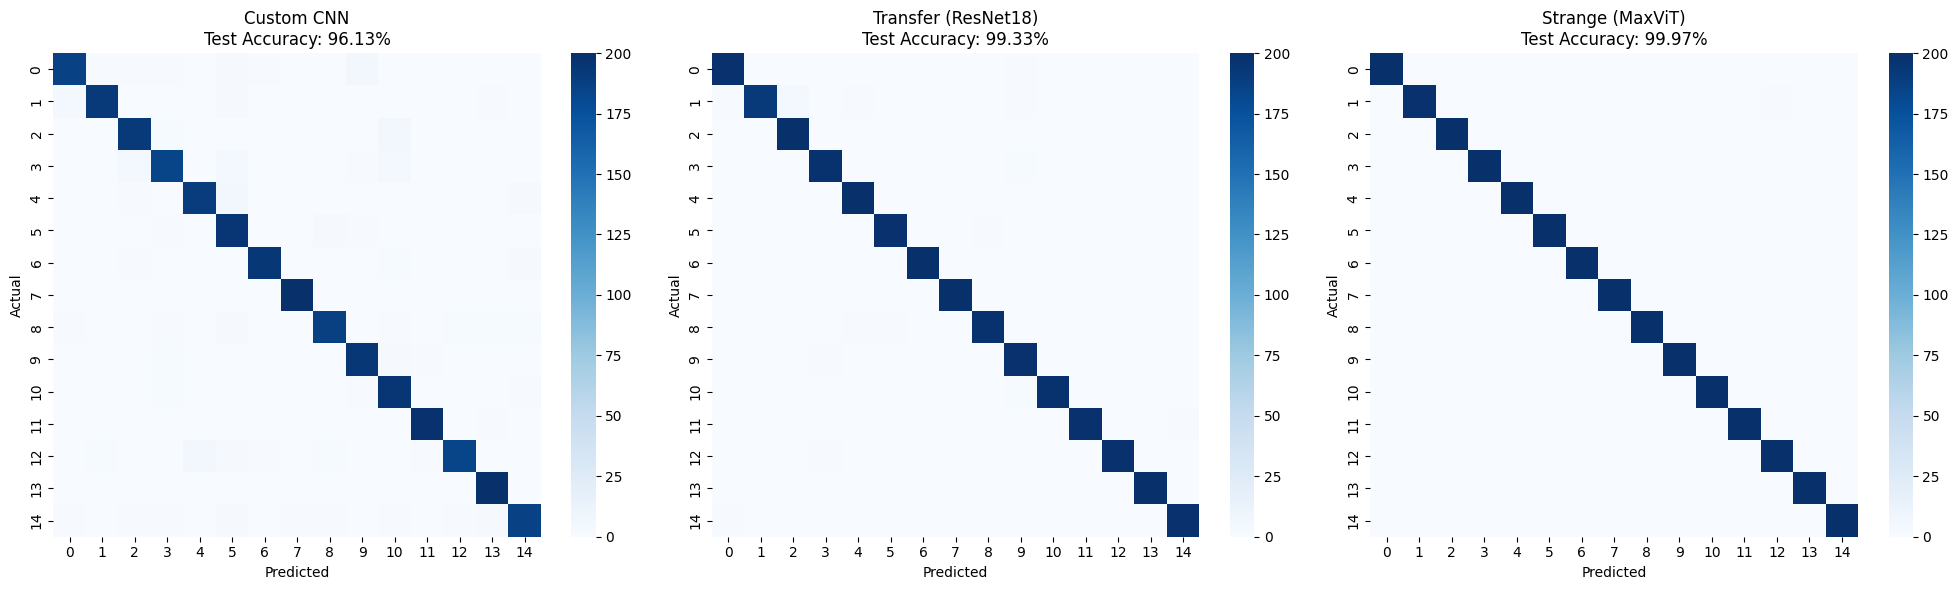

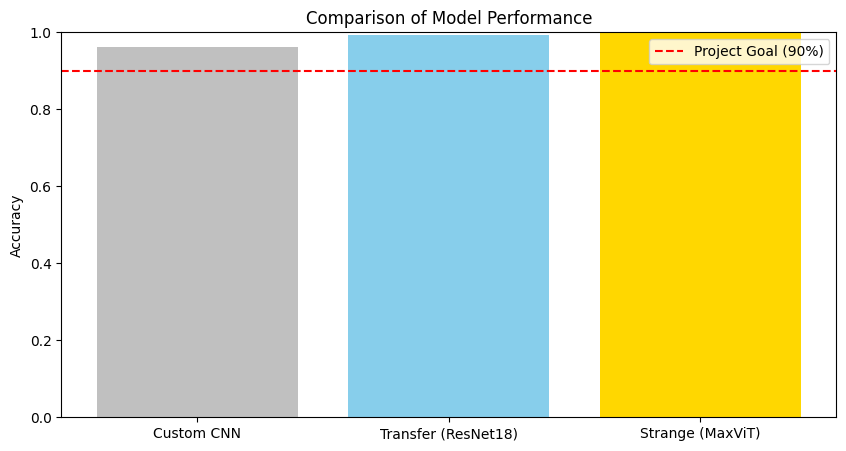

In [8]:
def evaluate_all_three(models_dict, test_loader):
    plt.figure(figsize=(20, 6))
    final_stats = {}

    for i, (name, model) in enumerate(models_dict.items()):
        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        acc = np.mean(np.array(all_preds) == np.array(all_labels))
        final_stats[name] = acc

        # Plotting Confusion Matrix
        plt.subplot(1, 3, i+1)
        cm = confusion_matrix(all_labels, all_preds)
        sns.heatmap(cm, annot=False, cmap='Blues')
        plt.title(f"{name}\nTest Accuracy: {acc:.2%}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

    # Final Comparative Performance Chart
    plt.figure(figsize=(10, 5))
    plt.bar(final_stats.keys(), final_stats.values(), color=['silver', 'skyblue', 'gold'])
    plt.axhline(y=0.9, color='r', linestyle='--', label='Project Goal (90%)')
    plt.ylabel('Accuracy')
    plt.title('Comparison of Model Performance')
    plt.ylim(0, 1.0)
    plt.legend()
    plt.show()

# Final evaluation using the models created in previous cells
evaluate_all_three({
    "Custom CNN": custom_model,
    "Transfer (ResNet18)": transfer_model,
    "Strange (MaxViT)": strange_model
}, test_loader)